In [1]:
import pandas as pd

In [2]:
# Load the new data
news = pd.read_csv('OnlineNewsPopularity.csv')

In [3]:
# Display the first 5 rows
news.head()

,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


In [5]:
import matplotlib.pyplot as plt

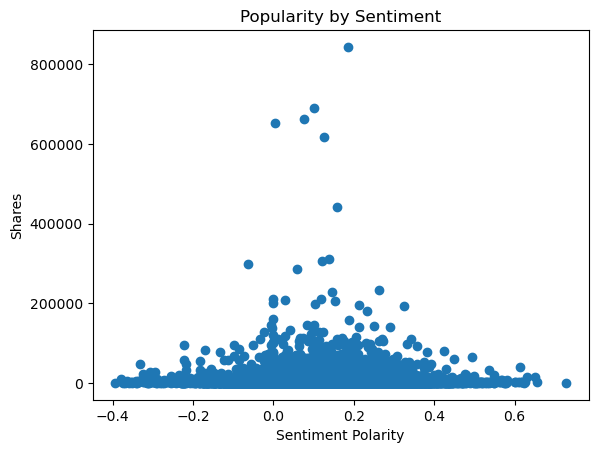

In [6]:
# Create a scatterplot of global sentiment polarity vs shares
plt.scatter(news[' global_sentiment_polarity'], news[' shares'])
plt.title("Popularity by Sentiment")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Shares")
plt.show()

## Using Linear Regression as a Prediction Model

In [8]:
# Create a linear regression model using global_sentiment_polarity and shares
# print the coefficient and y intercept values
from sklearn.linear_model import LinearRegression
X = news[' global_sentiment_polarity'].values.reshape(-1,1) # must reshape as there is only one column for X
y = news[' shares']
regressor = LinearRegression()
regressor.fit(X,y)
print(regressor.coef_)
print(regressor.intercept_)

[499.34840588]
3335.8032902095756


In [9]:
# Using the regressor model, predict the y values using X array
regline = regressor.predict(X)

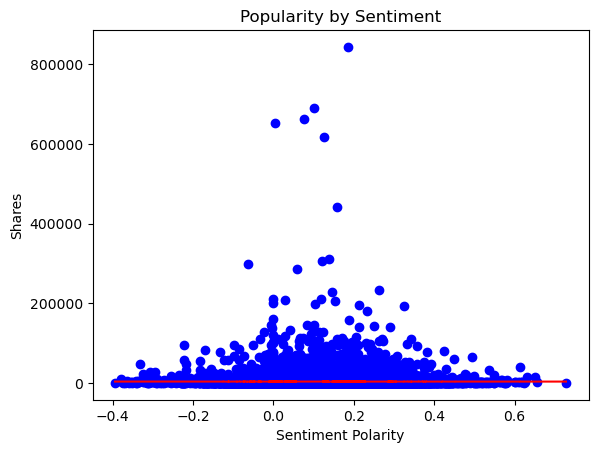

In [10]:
# Create a scatterplot of sentiment vs shares
plt.scatter(news[' global_sentiment_polarity'], news[' shares'], color='blue')

# Add the regressor line to the plot
plt.plot(sorted(news[' global_sentiment_polarity'].tolist()),regline, 'r')
plt.title("Popularity by Sentiment")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Shares")
plt.show()

## Implementing k-NN Manually

In [12]:
# Set the k nearest neighbors to 15 and the sentiment score to 0.5
k=15
newsentiment=0.5

In [13]:
# create lists of the sentiment and shares columns
allsentiment=news[' global_sentiment_polarity'].tolist()
allshares=news[' shares'].tolist()

In [14]:
# Calculate the absolute distances between allsentiment and the newsentiment score (0.5)
distances=[abs(x-newsentiment) for x in allsentiment]

In [15]:
import numpy as np

In [18]:
# Sort the distances from largest to smallest
# idx is short for index. this pull the index values out of the distances list
idx = np.argsort(distances)

In [19]:
# shows the top 15 index values of the sorted distances list
# these are the 15 closest articles to the sentiment value 0.5 above
print(idx[0:k])

[30230 22546  7284 13035 29598 19361 36029 30670 25556  6744 26473  7211
  9200 15198 31496]


In [20]:
# Get the shared values of the top 15 nearest articles
nearbyshares = [allshares[i] for i in idx[0:k]]

# show the shared values of the top 15 nearest articles to the sentiment value of 0.5
print(nearbyshares)

[3200, 3600, 467, 784, 18500, 1600, 1100, 1300, 4900, 868, 6400, 575, 773, 64500, 1600]


In [19]:
# The final prediction of number of shares an article with a 0.5 sentiment value would have
# this is a mean of the top 15 nearest neighbors
print(np.mean(nearbyshares))

7344.466666666666


## Performing k-NN with Python's sklearn

In [21]:
from sklearn.neighbors import KNeighborsRegressor

In [22]:
# Create the X and y arrays for KNN
X=np.array(allsentiment).reshape(-1,1)
y=np.array(allshares)

# Initiate a KNN regressor model and fit it to X,y
knnregressor = KNeighborsRegressor(n_neighbors=15)
knnregressor.fit(X,y)

KNeighborsRegressor(n_neighbors=15)

In [23]:
# Predict the number of shares with a 0.5 sentiment value
print(knnregressor.predict(np.array([newsentiment]).reshape(-1,1)))

[7344.46666667]


##### Observations: The manual and sklearn KNN regressor models predicted the same number of shares with a 0.5 sentiment value/

## Using Other Supervised Learning Algorithms

In [24]:
# Create the X and y arrays with sentiment and share values
X=np.array(allsentiment).reshape(-1,1)
y=np.array(allshares)

In [31]:
# Create a linear regression model
from sklearn.linear_model import LinearRegression
regressor=LinearRegression()
regressor.fit(X,y)
print(regressor.predict(np.array([newsentiment]).reshape(-1,1)))

[3585.47749315]


In [34]:
# Create a knn regressor model
from sklearn.neighbors import KNeighborsRegressor
knnregressor = KNeighborsRegressor(n_neighbors=15)
knnregressor.fit(X,y)
print(knnregressor.predict(np.array([newsentiment]).reshape(-1,1)))

[7344.46666667]


In [35]:
# Create a decision tree model
from sklearn.tree import DecisionTreeRegressor
dtregressor = DecisionTreeRegressor(max_depth=3)
dtregressor.fit(X,y)
print(dtregressor.predict(np.array([newsentiment]).reshape(-1,1)))

[3978.70776621]


In [36]:
# Create a random forest model
from sklearn.ensemble import RandomForestRegressor
rfregressor = RandomForestRegressor()
rfregressor.fit(X,y)
print(rfregressor.predict(np.array([newsentiment]).reshape(-1,1)))

[4489.268364]


In [43]:
# Create a nueral network model. I modified this from the original code to resolve convergence issue
from sklearn.neural_network import MLPRegressor
nnregressor = MLPRegressor(max_iter = 1000, 
                           learning_rate_init = 0.001,
                           learning_rate='adaptive',
                           n_iter_no_change=50)
nnregressor.fit(X,y)
print(dtregressor.predict(np.array([newsentiment]).reshape(-1,1)))

[3978.70776621]


##### Observation: 
 - Various models can produce different results
 - KNN regressor appears to be the most different from other models
 - The decision tree regressor and the MLP regressor produced the same results

## Measuring Prediction Accuracy Using MAE

In [30]:
P = np.array([allsentiment]).reshape(-1,1)

In [31]:
#linear regression MAE (mean absolute error)
allprediction=regressor.predict(P)
predictionerror=abs(allprediction-allsentiment)
print(np.mean(predictionerror))

3395.26087436506


In [32]:
#KNN MAE (mean absolute error)
allprediction=knnregressor.predict(P)
predictionerror=abs(allprediction-allsentiment)
print(np.mean(predictionerror))

3305.0234159854817


In [33]:
#Decision tree MAE (mean absolute error)
allprediction=dtregressor.predict(P)
predictionerror=abs(allprediction-allsentiment)
print(np.mean(predictionerror))

3395.26087436506


In [34]:
#Random forest MAE (mean absolute error)
allprediction=rfregressor.predict(P)
predictionerror=abs(allprediction-allsentiment)
print(np.mean(predictionerror))

3395.9339294394163


In [35]:
#Neural network MAE (mean absolute error)
allprediction=nnregressor.predict(P)
predictionerror=abs(allprediction-allsentiment)
print(np.mean(predictionerror))

3387.9180031471647


##### Observations:
 - Using the same data prediction is not proper methodology
 - Training and test sets are recommended
 - A validation set could also be added
 - MAE is realtively close for each model
 - KNN regressor has the lowest MAE value

#### Use train_test_split

In [48]:
from sklearn.model_selection import train_test_split

In [49]:
X=np.array(allsentiment).reshape(-1,1)
y=np.array(allshares)

In [50]:
# Split the X and y arays into training and test sets
trainingx, testx, trainingy, testy = train_test_split(X,y, random_state=1)

In [51]:
# Create a random forest regressor, predict using test data, and calculate MAE
rfregressor = RandomForestRegressor(random_state=1)
rfregressor.fit(trainingx, trainingy)
predicted = rfregressor.predict(testx)
predictionerror = abs(predicted-testy)
print(np.mean(predictionerror))

3813.8570912000273


In [52]:
# Create a KNN regressor, predict using test data, and calculate MAE
knnregressor = KNeighborsRegressor(n_neighbors=15)
knnregressor.fit(trainingx, trainingy)
predicted = knnregressor.predict(testx)
predicterror = abs(predicted-testy)
print(np.mean(predicterror))

3305.1753876164535


##### Observations: Based on MAE, KNN regressor performs better than the random forest regressor

## Working with Multivariate Models

In [53]:
# Create a multivariate random forest model, predict using test data, and calculate MAE
X=news[[' global_sentiment_polarity',' n_unique_tokens',' n_non_stop_words']]
y=np.array(allshares)
trainingx, testx, trainingy, testy = train_test_split(X,y, random_state=1)
rfregressor = RandomForestRegressor(random_state=1)
rfregressor.fit(trainingx, trainingy)
predicted = rfregressor.predict(testx)
predictionerror = abs(predicted-testy)
print(np.mean(predictionerror))

3474.231759738627


## Using Classification Instead of Regression

In [54]:
# Calculate the median value of the shares column
# Use the median value to create a new boolean field (0/1) 'abovemedianshares' 
themedian = np.median(news[' shares'])
news['abovemedianshares']=1*(news[' shares']>themedian)

In [57]:
from sklearn.neighbors import KNeighborsClassifier

In [58]:
# Create a KNN Classifier and predict y using test data
X=news[[' global_sentiment_polarity',' n_unique_tokens',' n_non_stop_words']]
y=np.array(news['abovemedianshares'])
trainingx, testx, trainingy, testy = train_test_split(X,y, random_state=1)
knnclassifier = KNeighborsClassifier(n_neighbors=15)
knnclassifier.fit(trainingx, trainingy)
predicted = knnclassifier.predict(testx)

In [59]:
from sklearn.metrics import confusion_matrix, precision_score, recall_score

In [60]:
# Create a confusion matrix
print(confusion_matrix(testy, predicted))

[[2833 2150]
 [2539 2389]]


In [62]:
# Calculate the precision and recall scores using sklearn
print(precision_score(testy, predicted))
print(recall_score(testy, predicted))

0.5263273848865389
0.48478084415584416
